# Forward rate agreements in QuantLib

Construct a receive-floating FRA, separate projection from discounting, and reconcile start settlement.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A desk FRA locks the rate for one future borrowing period. Here the long position receives floating and pays fixed on notional 100. It starts six months after 15 September 2026 and ends three index months later. The synthetic USD 3M index has zero fixing lag, Modified Following dates and Actual/360 accrual; it is not a live traded benchmark.

The notebook builds `IborIndex`, two `YieldTermStructureHandle` objects and `ForwardRateAgreement`. The index supplies projection; a separate handle supplies OIS discounting. The explicit-maturity constructor uses a discount-ratio forward. Choosing the end date from `index.maturityDate(start)` keeps this example aligned with the index period.

For the projected rate $L$, strike $K$ and accrual $\tau$, start settlement is $N\tau(L-K)/(1+\tau L)$. We reconstruct this amount and its discounted PV independently, check buyer/seller symmetry, and compare strikes 50 bp below, at and above the forward. QuantLib's constructor order is checked against the installed locked version; older Python examples can use a different order.

This is the library's deterministic forward substitution, not a stochastic settlement-convexity model. All fixings are future dates, so no historical fixing is silently supplied. A production ticket also needs its actual index, fixing availability, broken-date treatment and legal settlement convention. See the [QuantLib FRA implementation](https://github.com/lballabio/QuantLib/blob/master/ql/instruments/forwardrateagreement.cpp).

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
with valuation_date():
    discount, projection, _ = curves()
    discount_handle = ql.YieldTermStructureHandle(discount)
    projection_handle = ql.YieldTermStructureHandle(projection)
    index = ql.IborIndex('IllustrativeDesk3M', ql.Period('3M'), 0,
                        ql.USDCurrency(), CAL, ql.ModifiedFollowing, False,
                        ql.Actual360(), projection_handle)
    start = CAL.advance(DATE, ql.Period('6M'))
    end = index.maturityDate(start)
    tau = index.dayCounter().yearFraction(start, end)
    forward = (projection.discount(start)/projection.discount(end)-1)/tau
    rows = []
    for spread in [-.005, 0., .005]:
        strike = forward + spread
        buyer = ql.ForwardRateAgreement(index, start, end, ql.Position.Long,
                                       strike, 100., discount_handle)
        seller = ql.ForwardRateAgreement(index, start, end, ql.Position.Short,
                                        strike, 100., discount_handle)
        settlement = 100*tau*(forward-strike)/(1+tau*forward)
        manual_pv = settlement*discount.discount(start)
        assert abs(buyer.forwardRate().rate()-forward) < 1e-12
        assert abs(buyer.amount()-settlement) < 1e-12
        assert abs(buyer.NPV()-manual_pv) < 1e-12
        assert abs(buyer.NPV()+seller.NPV()) < 1e-12
        rows.append({'strike_pct':100*strike, 'forward_pct':100*forward,
                     'start_settlement':settlement, 'manual_PV':manual_pv,
                     'QuantLib_PV':buyer.NPV()})
    fra = pd.DataFrame(rows)
assert abs(fra.iloc[1].QuantLib_PV) < 1e-12
assert fra.iloc[0].QuantLib_PV > 0 > fra.iloc[2].QuantLib_PV
print(f'Accrual {start.ISO()} to {end.ISO()}; Actual/360 fraction {tau:.6f}')
display(fra.round(6))

Accrual 2027-03-15 to 2027-06-15; Actual/360 fraction 0.255556


,strike_pct,forward_pct,start_settlement,manual_PV,QuantLib_PV
0,3.739421,4.239421,0.126408,0.124061,0.124061
1,4.239421,4.239421,0.000000,0.000000,0.000000
2,4.739421,4.239421,-0.126408,-0.124061,-0.124061


## Economic relationship

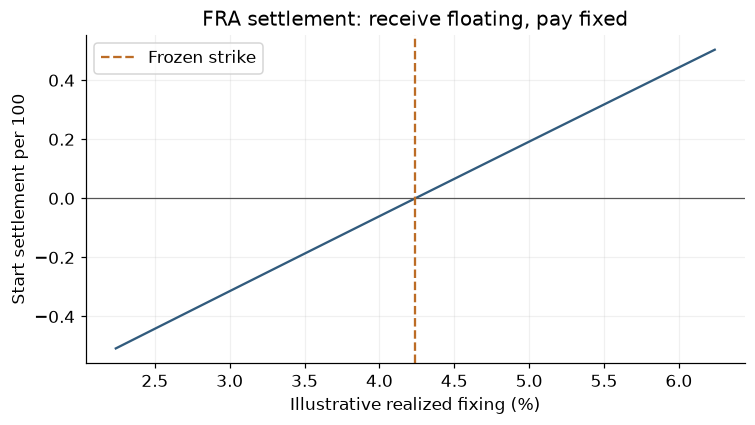

In [3]:
fixings = np.linspace(max(-.01, forward-.02), forward+.02, 80)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(100*fixings, 100*tau*(fixings-forward)/(1+tau*fixings), color='#315b7d')
ax.axhline(0, color='#555555', lw=.8)
ax.axvline(100*forward, color='#bc6c25', ls='--', label='Frozen strike')
ax.set(xlabel='Illustrative realized fixing (%)', ylabel='Start settlement per 100',
       title='FRA settlement: receive floating, pay fixed')
ax.legend(); fig.tight_layout(); plt.show()

## Interpretation

QuantLib agrees with independently calculated start settlement and discounted PV. The at-forward FRA is zero; reversing the position reverses value. Projection and discounting remain separate inputs.